In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [31]:
df = pd.read_csv('Crop_recommendation.csv')
df.head(5)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [32]:
label = df.groupby('label')
label

In [33]:
label.get_group('rice')

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
95,88,46,42,22.683191,83.463583,6.604993,194.265172,rice
96,93,47,37,21.533463,82.140041,6.500343,295.924880,rice
97,60,55,45,21.408658,83.329319,5.935745,287.576694,rice
98,78,35,44,26.543481,84.673536,7.072656,183.622266,rice


In [34]:
label[["humidity"]].mean()

,humidity
label,
apple,92.333383
banana,80.358123
blackgram,65.118426
chickpea,16.860439
coconut,94.844272
coffee,58.869846
cotton,79.843474
grapes,81.875228
jute,79.639864


In [35]:
label = list(label.mean().index)
label

['apple',
 'banana',
 'blackgram',
 'chickpea',
 'coconut',
 'coffee',
 'cotton',
 'grapes',
 'jute',
 'kidneybeans',
 'lentil',
 'maize',
 'mango',
 'mothbeans',
 'mungbean',
 'muskmelon',
 'orange',
 'papaya',
 'pigeonpeas',
 'pomegranate',
 'rice',
 'watermelon']

In [41]:
nitrogen = df.groupby('label')[['N']].mean().values.ravel().tolist()
nitrogen

[20.8,
 100.23,
 40.02,
 40.09,
 21.98,
 101.2,
 117.77,
 23.18,
 78.4,
 20.75,
 18.77,
 77.76,
 20.07,
 21.44,
 20.99,
 100.32,
 19.58,
 49.88,
 20.73,
 18.87,
 79.89,
 99.42]

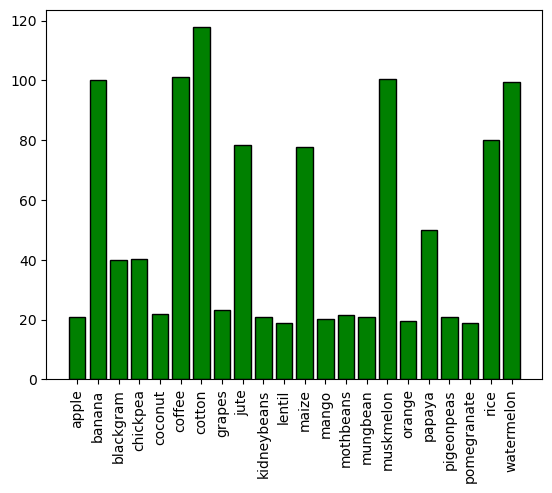

In [42]:
plt.bar(x = label, height = nitrogen, color = 'green', ec = "k")
plt.xticks(rotation = 90)
plt.show()


In [ ]:
x = df.drop("label",axis=1)


In [43]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_transformed = sc.fit_transform(x)
x_transformed.shape

(2200, 7)

In [50]:
desc = pd.DataFrame(x_transformed, columns=x.columns).describe().T
desc.head()

,count,mean,std,min,25%,50%,75%,max
N,2200.0,-1.033517e-16,1.000227,-1.369636,-0.800668,-0.367169,0.913009,2.423483
P,2200.0,5.167584e-17,1.000227,-1.466498,-0.769071,-0.071645,0.443844,2.778707
K,2200.0,-5.167584e-17,1.000227,-0.852136,-0.555906,-0.318922,0.016804,3.097591
temperature,2200.0,3.875688e-16,1.000227,-3.316592,-0.562334,-0.003467,0.581798,3.567190
humidity,2200.0,-1.808654e-16,1.000227,-2.570842,-0.504064,0.403947,0.829651,1.280400


In [51]:
desc_formatted = desc.applymap(lambda x: f"{x:.2f}")
desc_formatted.head()


C:\Users\CC\AppData\Local\Temp\ipykernel_22436\3593669588.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  desc_formatted = desc.applymap(lambda x: f"{x:.2f}")


,count,mean,std,min,25%,50%,75%,max
N,2200.00,-0.00,1.00,-1.37,-0.80,-0.37,0.91,2.42
P,2200.00,0.00,1.00,-1.47,-0.77,-0.07,0.44,2.78
K,2200.00,-0.00,1.00,-0.85,-0.56,-0.32,0.02,3.10
temperature,2200.00,0.00,1.00,-3.32,-0.56,-0.00,0.58,3.57
humidity,2200.00,-0.00,1.00,-2.57,-0.50,0.40,0.83,1.28


In [ ]:
from sklearn.cluster import KMeans
KMeans = KMeans()
KMeans.fit(x_transformed)

c:\Users\CC\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\CC\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\CC\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\CC\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\CC\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable

KMeans()

In [53]:
label = KMeans.labels_

In [54]:
df['cluster_8'] = label
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,cluster_8
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,6
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,6
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,6
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,6
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,6


In [56]:
df["cluster_8"].value_counts()

cluster_8
4    521
2    396
6    296
1    221
5    200
3    200
0    188
7    178
Name: count, dtype: int64

In [58]:
df[df["cluster_8"] == 5]["label"].value_counts()

label
mango         88
pigeonpeas    69
mothbeans     42
lentil         1
Name: count, dtype: int64

In [59]:
df[df["cluster_8"] == 3]["label"].value_counts()


label
grapes    100
apple     100
Name: count, dtype: int64

In [60]:
from sklearn.metrics import silhouette_score
silhouette_score(x_transformed, label)

0.33408640165096853

In [65]:
WCSS = {}
for i in range(5, 51):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(x_transformed)
    WCSS[i] = kmeans.inertia_


c:\Users\CC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\CC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\CC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\CC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

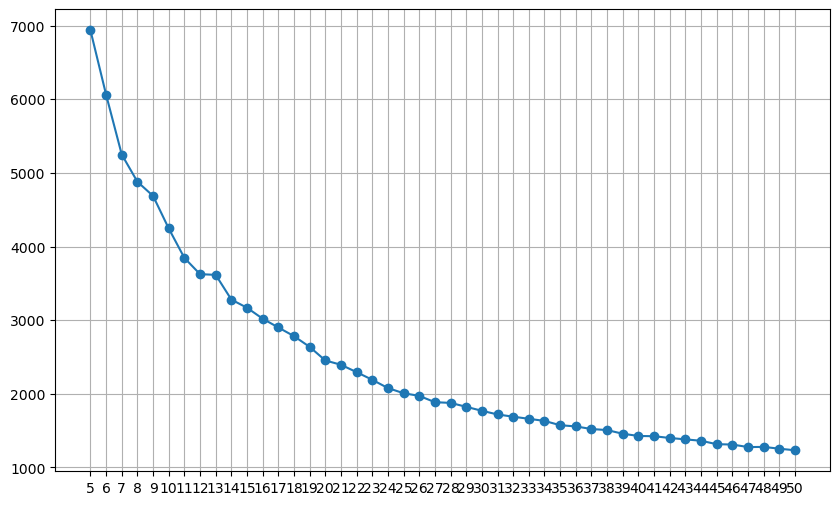

In [67]:
plt.figure(figsize=(10, 6))
plt.plot(WCSS.keys(), WCSS.values(), marker='o')
plt.xticks(list(WCSS.keys()))
plt.grid(True)
plt.show()

In [68]:
import joblib
joblib.dump(KMeans, 'crop_reco_kmeans.lb')

['crop_reco_kmeans.lb']

In [69]:
joblib.dump(sc, "scaler.lb")

['scaler.lb']

In [71]:
joblib.dump(sc, 'crop_reco_df.lb')

['crop_reco_df.lb']